# Model Calibration to Implied Vol Surface

This notebook demonstrates calibrating stochastic volatility and Lévy models to a (maturities × strikes) implied vol surface.

**Models covered**: Heston, Variance Gamma, NIG, and SABR

**Approach**: Minimise sum of squared IV residuals (model IV − market IV) using Nelder-Mead over a normalised parameter box.

**Reference**: Cont & Tankov (2004), *Financial Modelling with Jump Processes*, Ch. 13.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from foureng.surface.vol_surface import SurfaceSpec, model_iv_surface
from foureng.surface.calibration import (
    calibrate_heston,
    calibrate_vg,
    calibrate_nig,
    calibrate_sabr_smile,
)
from foureng.models.heston import HestonParams, heston_cf_form2, heston_cumulants
from foureng.models.variance_gamma import VGParams, vg_cf, vg_cumulants
from foureng.models.nig import NigParams, nig_cf, nig_cumulants
from foureng.models.sabr import SabrParams, sabr_hagan_implied_vol

# Surface grid
S0, r, q = 100.0, 0.05, 0.0
MATS    = np.array([0.25, 0.5, 1.0, 1.5, 2.0])
STRIKES = np.array([80., 85., 90., 95., 100., 105., 110., 115., 120.])

SPEC = SurfaceSpec(S0=S0, r=r, q=q, maturities=MATS, strikes=STRIKES)

---
## 1. Heston model calibration

The Heston (1993) stochastic volatility model:

$$dS = (r-q)S\,dt + \sqrt{v}\,S\,dW_1, \quad dv = \kappa(\theta - v)\,dt + \nu\sqrt{v}\,dW_2, \quad \langle dW_1,dW_2\rangle = \rho\,dt$$

We generate a synthetic market surface from known parameters, then calibrate back to recover them.

In [2]:
# True Heston parameters
true_heston = HestonParams(kappa=2.0, theta=0.04, nu=0.3, rho=-0.5, v0=0.04)

# Generate synthetic market IVs
mkt_ivs_heston = model_iv_surface(
    SPEC,
    cf_factory=lambda fwd: lambda u: heston_cf_form2(u, fwd, true_heston),
    cumulant_factory=lambda fwd: heston_cumulants(fwd, true_heston),
    N=192,
)

print('True Heston params:', true_heston)
print(f'Market IV surface shape: {mkt_ivs_heston.shape}  (nT={len(MATS)}, nK={len(STRIKES)})')
print(f'ATM IVs across maturities: {mkt_ivs_heston[:, 4].round(4)}')

True Heston params: HestonParams(name='heston', kappa=2.0, theta=0.04, nu=0.3, rho=-0.5, v0=0.04)
Market IV surface shape: (5, 9)  (nT=5, nK=9)
ATM IVs across maturities: [0.1981 0.1975 0.1978 0.1987 0.1995]


In [3]:
# Calibrate from a perturbed starting point
init_heston = HestonParams(kappa=1.5, theta=0.06, nu=0.25, rho=-0.3, v0=0.06)

result_heston = calibrate_heston(SPEC, mkt_ivs_heston, initial=init_heston, maxiter=3000)

print(f'Calibrated in {result_heston.nfev} function evaluations')
print(f'Final loss (sum sq IV residuals): {result_heston.loss:.2e}')
print(f'Max absolute IV residual:         {np.max(np.abs(result_heston.residuals)):.2e}')
print()
print('Calibrated params:')
for k, v in result_heston.params.items():
    if isinstance(v, (int, float)):
        print(f'  {k:6s}: {v:.4f}')

Calibrated in 507 function evaluations
Final loss (sum sq IV residuals): 3.28e-14
Max absolute IV residual:         5.69e-08

Calibrated params:
  kappa : 2.0000
  theta : 0.0400
  nu    : 0.3000
  rho   : -0.5000
  v0    : 0.0400


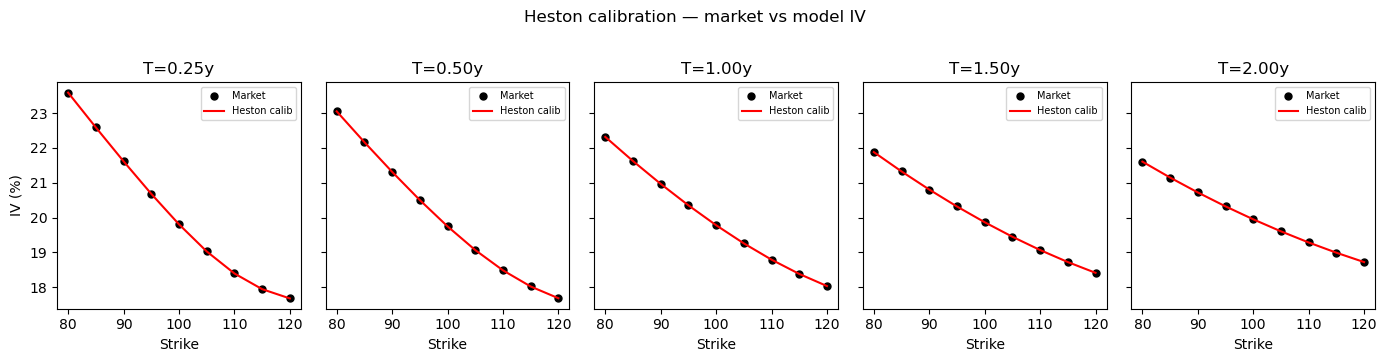

In [4]:
# Plot market vs calibrated smile at each maturity
_p = {k: v for k, v in result_heston.params.items() if k != 'name'}
calib_p = HestonParams(**_p)
calib_ivs = model_iv_surface(
    SPEC,
    cf_factory=lambda fwd: lambda u: heston_cf_form2(u, fwd, calib_p),
    cumulant_factory=lambda fwd: heston_cumulants(fwd, calib_p),
    N=192,
)

fig, axes = plt.subplots(1, len(MATS), figsize=(14, 3.5), sharey=True)
for i, (T, ax) in enumerate(zip(MATS, axes)):
    ax.plot(STRIKES, mkt_ivs_heston[i] * 100, 'ko', ms=5, label='Market')
    ax.plot(STRIKES, calib_ivs[i] * 100, 'r-', lw=1.5, label='Heston calib')
    ax.set_title(f'T={T:.2f}y')
    ax.set_xlabel('Strike')
    if i == 0:
        ax.set_ylabel('IV (%)')
    ax.legend(fontsize=7)
plt.suptitle('Heston calibration — market vs model IV', y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Variance Gamma calibration

The VG model (Madan, Carr & Chang 1998): pure-jump process obtained by Brownian-motion time-changed by a Gamma process.

$$X_{VG}(t) = \theta\, G(t) + \sigma\, W(G(t))$$

where $G(t)$ is a Gamma process with unit mean and variance $\nu t$.

In [5]:
true_vg = VGParams(sigma=0.15, nu=0.5, theta=-0.10)

mkt_ivs_vg = model_iv_surface(
    SPEC,
    cf_factory=lambda fwd: lambda u: vg_cf(u, fwd, true_vg),
    cumulant_factory=lambda fwd: vg_cumulants(fwd, true_vg),
    N=512,
)

init_vg = VGParams(sigma=0.18, nu=0.4, theta=-0.05)
result_vg = calibrate_vg(SPEC, mkt_ivs_vg, initial=init_vg, maxiter=3000)

print(f'VG loss: {result_vg.loss:.2e}  |  nfev: {result_vg.nfev}')
_vg = {k: v for k, v in result_vg.params.items() if k != 'name'}
print('Calibrated:', _vg)

VG loss: 5.04e-13  |  nfev: 180
Calibrated: {'sigma': 0.15000017021199397, 'nu': 0.49999994881729626, 'theta': -0.0999998390522574}


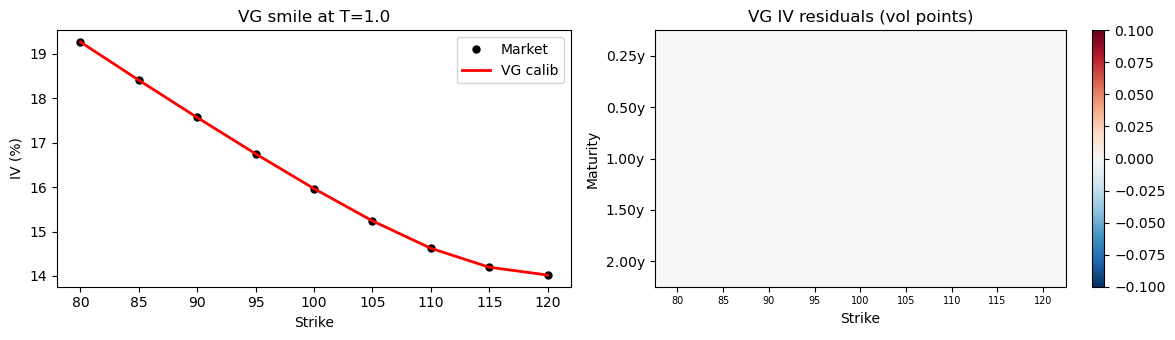

In [6]:
_vg = {k: v for k, v in result_vg.params.items() if k != 'name'}
calib_vg = VGParams(**_vg)
calib_ivs_vg = model_iv_surface(
    SPEC,
    cf_factory=lambda fwd: lambda u: vg_cf(u, fwd, calib_vg),
    cumulant_factory=lambda fwd: vg_cumulants(fwd, calib_vg),
    N=512,
)

# Show residual heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))

# Left: smiles at T=1.0
T_idx = np.searchsorted(MATS, 1.0)
ax1.plot(STRIKES, mkt_ivs_vg[T_idx] * 100, 'ko', ms=5, label='Market')
ax1.plot(STRIKES, calib_ivs_vg[T_idx] * 100, 'r-', lw=2, label='VG calib')
ax1.set_xlabel('Strike')
ax1.set_ylabel('IV (%)')
ax1.set_title('VG smile at T=1.0')
ax1.legend()

# Right: residual heatmap
resid = result_vg.residuals * 100
im = ax2.imshow(resid, aspect='auto', cmap='RdBu_r', vmin=-0.1, vmax=0.1)
ax2.set_xticks(range(len(STRIKES)))
ax2.set_xticklabels([int(k) for k in STRIKES], fontsize=7)
ax2.set_yticks(range(len(MATS)))
ax2.set_yticklabels([f'{t:.2f}y' for t in MATS])
ax2.set_xlabel('Strike')
ax2.set_ylabel('Maturity')
ax2.set_title('VG IV residuals (vol points)')
plt.colorbar(im, ax=ax2)
plt.tight_layout()
plt.show()

---
## 3. SABR smile calibration

SABR is typically calibrated maturity-by-maturity.  The Hagan approximation gives vols directly, so calibration is **much faster** than COS-based methods.

We fit $(\alpha, \rho, \nu)$ with $\beta$ fixed (a common market convention).

In [7]:
# Synthetic SABR market smile at T=1
F, T_sabr, beta = 100.0, 1.0, 0.5
K_sabr = np.array([80., 85., 90., 95., 100., 105., 110., 115., 120.])
true_sabr = SabrParams(alpha=0.30, beta=beta, rho=-0.40, nu=0.50)

mkt_sabr_ivs = sabr_hagan_implied_vol(F, K_sabr, T_sabr,
                                       true_sabr.alpha, true_sabr.beta,
                                       true_sabr.rho,   true_sabr.nu)

# Add a little noise to simulate real market data
rng = np.random.default_rng(42)
noisy_ivs = mkt_sabr_ivs + rng.normal(0, 0.001, size=mkt_sabr_ivs.shape)

# Calibrate
init_sabr = SabrParams(alpha=0.35, beta=beta, rho=-0.2, nu=0.3)
res_sabr = calibrate_sabr_smile(F, T_sabr, K_sabr, noisy_ivs, initial=init_sabr)

print(f'SABR calibration: loss={res_sabr.loss:.2e}, nfev={res_sabr.nfev}')
print(f"True params: alpha={true_sabr.alpha:.3f}, rho={true_sabr.rho:.3f}, nu={true_sabr.nu:.3f}")
print(f"Fitted:      alpha={res_sabr.params.alpha:.3f}, rho={res_sabr.params.rho:.3f}, nu={res_sabr.params.nu:.3f}")

SABR calibration: loss=5.98e-06, nfev=233
True params: alpha=0.300, rho=-0.400, nu=0.500
Fitted:      alpha=0.291, rho=-0.410, nu=0.518


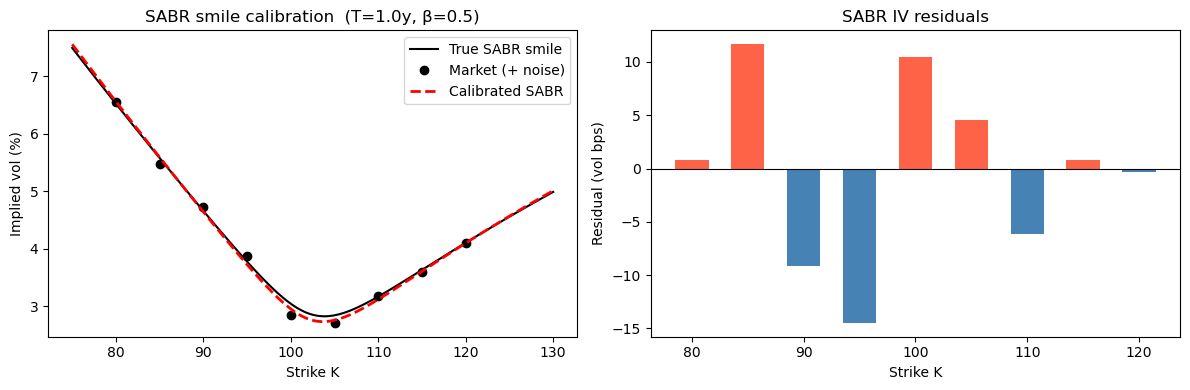

In [8]:
# Plot SABR calibration
K_fine = np.linspace(75, 130, 200)
true_fine = sabr_hagan_implied_vol(F, K_fine, T_sabr,
                                    true_sabr.alpha, beta, true_sabr.rho, true_sabr.nu)
calib_fine = sabr_hagan_implied_vol(F, K_fine, T_sabr,
                                     res_sabr.params.alpha, beta,
                                     res_sabr.params.rho, res_sabr.params.nu)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_fine, true_fine * 100, 'k-', lw=1.5, label='True SABR smile')
ax1.plot(K_sabr, noisy_ivs * 100, 'ko', ms=6, label='Market (+ noise)')
ax1.plot(K_fine, calib_fine * 100, 'r--', lw=2, label='Calibrated SABR')
ax1.set_xlabel('Strike K')
ax1.set_ylabel('Implied vol (%)')
ax1.set_title(f'SABR smile calibration  (T={T_sabr}y, β={beta})')
ax1.legend()

ax2.bar(K_sabr, res_sabr.residuals * 10_000, width=3, color=['tomato' if r > 0 else 'steelblue' for r in res_sabr.residuals])
ax2.axhline(0, color='k', lw=0.8)
ax2.set_xlabel('Strike K')
ax2.set_ylabel('Residual (vol bps)')
ax2.set_title('SABR IV residuals')

plt.tight_layout()
plt.show()

### 3.2  Multi-maturity SABR calibration

Calibrate one smile per maturity, plotting the term structure of SABR parameters.

T=0.25: loss=1.61e-18  α=0.350  ρ=-0.500  ν=0.600
T=0.50: loss=1.05e-18  α=0.320  ρ=-0.450  ν=0.550
T=1.00: loss=1.68e-19  α=0.300  ρ=-0.400  ν=0.500
T=1.50: loss=1.70e-19  α=0.280  ρ=-0.380  ν=0.480
T=2.00: loss=4.43e-20  α=0.270  ρ=-0.350  ν=0.450


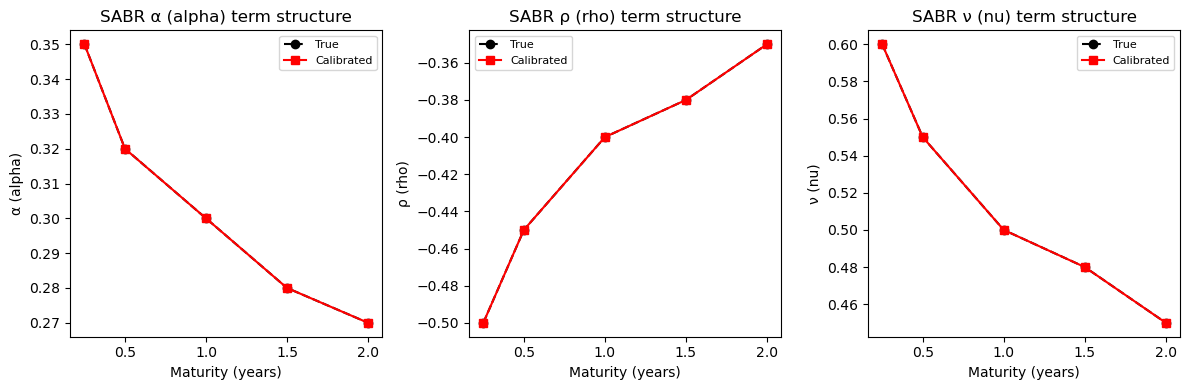

In [9]:
# True SABR params vary with maturity (term structure)
true_params_by_mat = [
    SabrParams(alpha=0.35, beta=0.5, rho=-0.50, nu=0.60),  # T=0.25
    SabrParams(alpha=0.32, beta=0.5, rho=-0.45, nu=0.55),  # T=0.50
    SabrParams(alpha=0.30, beta=0.5, rho=-0.40, nu=0.50),  # T=1.00
    SabrParams(alpha=0.28, beta=0.5, rho=-0.38, nu=0.48),  # T=1.50
    SabrParams(alpha=0.27, beta=0.5, rho=-0.35, nu=0.45),  # T=2.00
]

calib_by_mat = []
for T_val, tp in zip(MATS, true_params_by_mat):
    F_t = S0 * np.exp((r - q) * T_val)
    true_smile = sabr_hagan_implied_vol(F_t, STRIKES, T_val, tp.alpha, tp.beta, tp.rho, tp.nu)
    init = SabrParams(alpha=tp.alpha * 1.15, beta=0.5, rho=tp.rho * 0.8, nu=tp.nu * 1.2)
    res = calibrate_sabr_smile(F_t, T_val, STRIKES, true_smile, initial=init, maxiter=5000)
    calib_by_mat.append(res)
    print(f'T={T_val:.2f}: loss={res.loss:.2e}  α={res.params.alpha:.3f}  ρ={res.params.rho:.3f}  ν={res.params.nu:.3f}')

# Plot term structure
alphas = [r.params.alpha for r in calib_by_mat]
rhos   = [r.params.rho   for r in calib_by_mat]
nus    = [r.params.nu    for r in calib_by_mat]
true_alphas = [tp.alpha for tp in true_params_by_mat]
true_rhos   = [tp.rho   for tp in true_params_by_mat]
true_nus    = [tp.nu    for tp in true_params_by_mat]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, calib_vals, true_vals, label in [
    (axes[0], alphas, true_alphas, 'α (alpha)'),
    (axes[1], rhos,   true_rhos,   'ρ (rho)'),
    (axes[2], nus,    true_nus,    'ν (nu)'),
]:
    ax.plot(MATS, true_vals, 'k--o', label='True')
    ax.plot(MATS, calib_vals, 'r-s', label='Calibrated')
    ax.set_xlabel('Maturity (years)')
    ax.set_ylabel(label)
    ax.set_title(f'SABR {label} term structure')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 4. Model comparison: Heston vs VG vs NIG on the same surface

Fit all three models to the same synthetic Heston surface and compare out-of-sample residuals.

In [10]:
# Reference: Heston surface
mkt = mkt_ivs_heston

# Calibrate VG and NIG to the Heston surface
res_vg2  = calibrate_vg(SPEC, mkt, initial=VGParams(sigma=0.15, nu=0.3, theta=-0.05), maxiter=3000)
res_nig2 = calibrate_nig(SPEC, mkt, initial=NigParams(sigma=0.15, nu=0.3, theta=-0.05), maxiter=3000)

# Calibrate Heston to itself
res_h2   = calibrate_heston(SPEC, mkt, initial=HestonParams(kappa=1.5, theta=0.05, nu=0.25, rho=-0.3, v0=0.05), maxiter=3000)

print(f'Heston loss: {res_h2.loss:.2e}  (should be ~0 — Heston fits its own surface)')
print(f'VG loss:     {res_vg2.loss:.2e}  (VG can approximate Heston smile)')
print(f'NIG loss:    {res_nig2.loss:.2e}  (NIG shape is similar to VG)')

Heston loss: 1.06e-14  (should be ~0 — Heston fits its own surface)
VG loss:     1.48e-03  (VG can approximate Heston smile)
NIG loss:    1.48e-03  (NIG shape is similar to VG)


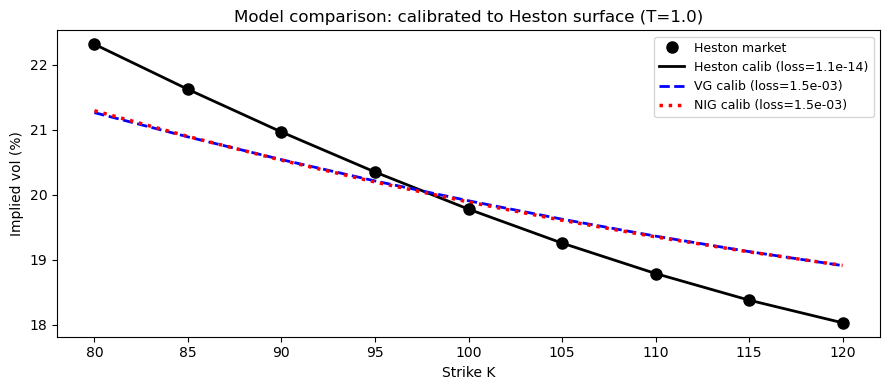

In [11]:
# Compute calibrated model IVs
calib_vg2  = VGParams(**{k: v for k, v in res_vg2.params.items() if k != 'name'})
calib_nig2 = NigParams(**{k: v for k, v in res_nig2.params.items() if k != 'name'})
calib_h2   = HestonParams(**{k: v for k, v in res_h2.params.items() if k != 'name'})

ivs_vg2  = model_iv_surface(SPEC, lambda fwd: lambda u: vg_cf(u, fwd, calib_vg2),  lambda fwd: vg_cumulants(fwd, calib_vg2),  N=512)
ivs_nig2 = model_iv_surface(SPEC, lambda fwd: lambda u: nig_cf(u, fwd, calib_nig2), lambda fwd: nig_cumulants(fwd, calib_nig2), N=512)
ivs_h2   = model_iv_surface(SPEC, lambda fwd: lambda u: heston_cf_form2(u, fwd, calib_h2), lambda fwd: heston_cumulants(fwd, calib_h2), N=192)

# Plot at T=1
T_idx = np.searchsorted(MATS, 1.0)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(STRIKES, mkt[T_idx] * 100, 'ko', ms=8, label='Heston market', zorder=5)
ax.plot(STRIKES, ivs_h2[T_idx]  * 100, 'k-',  lw=2, label=f'Heston calib (loss={res_h2.loss:.1e})')
ax.plot(STRIKES, ivs_vg2[T_idx] * 100, 'b--', lw=2, label=f'VG calib (loss={res_vg2.loss:.1e})')
ax.plot(STRIKES, ivs_nig2[T_idx]* 100, 'r:',  lw=2.5, label=f'NIG calib (loss={res_nig2.loss:.1e})')
ax.set_xlabel('Strike K')
ax.set_ylabel('Implied vol (%)')
ax.set_title('Model comparison: calibrated to Heston surface (T=1.0)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()